In [2]:
import pandas as pd #data manipulation, analysis, and handling tabular datasets
import pyarrow as pa # PyArrow library for efficient in-memory columnar data processing
import pyarrow.parquet as pq #PyArrow Parquet module to read and write Parquet files
import os ## Import os module to interact with the operating system
# Used for file path handling, checking file sizes, and file management

In [3]:
pip install pandas pyarrow psutil

Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
os.getcwd()

'C:\\Users\\ASUS'

In [5]:
loans = pd.read_csv("loans_master.csv")
customer = pd.read_csv("customer_bureau.csv")
payment = pd.read_csv("payment_history.csv")
performance = pd.read_csv("loan_performance.csv")
enquiry = pd.read_csv("loan_enquiry_bureau.csv")
credit_card = pd.read_csv("credit_card_behavior.csv")
collateral = pd.read_csv("collateral_assets.csv")
branch = pd.read_csv("branch_region_economy.csv")
monthly_emi_tracker = pd.read_csv("monthly_emi_track.csv")

In [6]:
loans.shape

(2000000, 27)

In [7]:
customer.shape

(2000000, 30)

In [8]:
payment.shape

(2000000, 18)

In [9]:
performance.shape

(2000000, 12)

In [10]:
enquiry.shape

(2000000, 24)

In [11]:
credit_card.shape

(2000000, 17)

In [12]:
collateral.shape

(2000000, 20)

In [13]:
branch.shape

(2000000, 19)

In [14]:
monthly_emi_tracker.shape

(2000000, 23)

In [15]:
def csv_to_parquet_optimized(csv_file, parquet_file):

    # --------------------------------------------------
    # Step 1: Load CSV file
    # --------------------------------------------------
    print(f"\nProcessing: {csv_file}")

    df = pd.read_csv(csv_file, low_memory=False)

    # --------------------------------------------------
    # Step 2: Memory BEFORE optimization
    # --------------------------------------------------
    memory_before = df.memory_usage(deep=True).sum() / 1024**2

    # --------------------------------------------------
    # Step 3: Optimize Data Types (Memory Reduction)
    # --------------------------------------------------

    # Convert int64 → smaller integer type (int8, int16, etc.)
    for col in df.select_dtypes(include=['int64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='integer')

    # Convert float64 → float32 (or smaller if possible)
    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='float')

    # Convert object columns → category (huge memory saving for repeated values)
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].astype('category')

    # --------------------------------------------------
    # Step 4: Memory AFTER optimization
    # --------------------------------------------------
    memory_after = df.memory_usage(deep=True).sum() / 1024**2

    # --------------------------------------------------
    # Step 5: Calculate memory reduction %
    # --------------------------------------------------
    reduction = ((memory_before - memory_after) / memory_before) * 100

    # --------------------------------------------------
    # Step 6: Save as Parquet (compressed format)
    # --------------------------------------------------
    df.to_parquet(parquet_file, index=False)

    parquet_size = os.path.getsize(parquet_file) / 1024**2

    # --------------------------------------------------
    # Step 7: Print results
    # --------------------------------------------------
    print(f"Memory Before : {memory_before:.2f} MB")
    print(f"Memory After  : {memory_after:.2f} MB")
    print(f"Reduction     : {reduction:.2f}%")
    print(f"Parquet Size  : {parquet_size:.2f} MB")

    return df

In [16]:
loans = csv_to_parquet_optimized("loans_master.csv", "loans.parquet")


Processing: loans_master.csv
Memory Before : 1564.73 MB
Memory After  : 310.57 MB
Reduction     : 80.15%
Parquet Size  : 78.30 MB


In [17]:
customer = csv_to_parquet_optimized("customer_bureau.csv", "customer_bureau.parquet")


Processing: customer_bureau.csv
Memory Before : 1014.09 MB
Memory After  : 482.87 MB
Reduction     : 52.38%
Parquet Size  : 119.49 MB


In [18]:
payment = csv_to_parquet_optimized("payment_history.csv", "payment_history.parquet")


Processing: payment_history.csv
Memory Before : 373.84 MB
Memory After  : 371.58 MB
Reduction     : 0.60%
Parquet Size  : 87.04 MB


In [19]:
performance = csv_to_parquet_optimized("loan_performance.csv", "loan_performance.parquet")


Processing: loan_performance.csv
Memory Before : 558.29 MB
Memory After  : 266.68 MB
Reduction     : 52.23%
Parquet Size  : 38.45 MB


In [20]:
enquiry = csv_to_parquet_optimized("loan_enquiry_bureau.csv", "loan_enquiry_bureau.parquet")


Processing: loan_enquiry_bureau.csv
Memory Before : 1109.23 MB
Memory After  : 255.25 MB
Reduction     : 76.99%
Parquet Size  : 55.03 MB


In [21]:
credit_card = csv_to_parquet_optimized("credit_card_behavior.csv", "credit_card_behavior.parquet")


Processing: credit_card_behavior.csv
Memory Before : 587.13 MB
Memory After  : 262.87 MB
Reduction     : 55.23%
Parquet Size  : 59.08 MB


In [22]:
collateral = csv_to_parquet_optimized("collateral_assets.csv", "collateral_assets.parquet")


Processing: collateral_assets.csv
Memory Before : 844.51 MB
Memory After  : 276.23 MB
Reduction     : 67.29%
Parquet Size  : 44.81 MB


In [23]:
branch = csv_to_parquet_optimized("branch_region_economy.csv", "branch_region_economy.parquet")


Processing: branch_region_economy.csv
Memory Before : 664.13 MB
Memory After  : 292.06 MB
Reduction     : 56.02%
Parquet Size  : 53.43 MB


In [24]:
monthly_emi_tracker = csv_to_parquet_optimized("monthly_emi_track.csv", "monthly_emi_track.parquet")


Processing: monthly_emi_track.csv
Memory Before : 808.17 MB
Memory After  : 346.80 MB
Reduction     : 57.09%
Parquet Size  : 89.09 MB


In [25]:
# --------------------------------------------------
# Step 1: Define file mapping (dataset name → file)
# --------------------------------------------------
parquet_files = {
    "loans": "loans.parquet",
    "customer": "customer_bureau.parquet",
    "payment": "payment_history.parquet",
    "performance": "loan_performance.parquet",
    "enquiry": "loan_enquiry_bureau.parquet",
    "credit": "credit_card_behavior.parquet",
    "collateral": "collateral_assets.parquet",
    "branch": "branch_region_economy.parquet",
    "emi": "monthly_emi_track.parquet"
}

# --------------------------------------------------
# Step 2: Dictionary to store DataFrames
# --------------------------------------------------
dataframes = {}

# --------------------------------------------------
# Step 3: Load each parquet file into dictionary
# --------------------------------------------------
for name, file in parquet_files.items():
    
    print(f"Loading: {name} -> {file}")
    
    dataframes[name] = pd.read_parquet(
        f"C:\\Users\\ASUS\\{file}"
    )

print("\nAll files loaded successfully!")

Loading: loans -> loans.parquet
Loading: customer -> customer_bureau.parquet
Loading: payment -> payment_history.parquet
Loading: performance -> loan_performance.parquet
Loading: enquiry -> loan_enquiry_bureau.parquet
Loading: credit -> credit_card_behavior.parquet
Loading: collateral -> collateral_assets.parquet
Loading: branch -> branch_region_economy.parquet
Loading: emi -> monthly_emi_track.parquet

All files loaded successfully!


In [26]:
for name, df in dataframes.items():

    print("\n", name)

    print("Rows:", len(df))

    print("Unique Loan IDs:",
          df.loan_id.nunique())

    print("Duplicate Loan IDs:",
          df.loan_id.duplicated().sum())


 loans
Rows: 2000000
Unique Loan IDs: 2000000
Duplicate Loan IDs: 0

 customer
Rows: 2000000
Unique Loan IDs: 2000000
Duplicate Loan IDs: 0

 payment
Rows: 2000000
Unique Loan IDs: 2000000
Duplicate Loan IDs: 0

 performance
Rows: 2000000
Unique Loan IDs: 2000000
Duplicate Loan IDs: 0

 enquiry
Rows: 2000000
Unique Loan IDs: 2000000
Duplicate Loan IDs: 0

 credit
Rows: 2000000
Unique Loan IDs: 2000000
Duplicate Loan IDs: 0

 collateral
Rows: 2000000
Unique Loan IDs: 2000000
Duplicate Loan IDs: 0

 branch
Rows: 2000000
Unique Loan IDs: 2000000
Duplicate Loan IDs: 0

 emi
Rows: 2000000
Unique Loan IDs: 2000000
Duplicate Loan IDs: 0


Q1(b) Join all nine tables on loan_id using sequential left merges. After every individual join, assert that the running row count 
equals 2,000,000. Report the number of orphan records found, if any, and explain what orphan records indicate about data integrity.

In [27]:
base_df = dataframes["loans"].copy()

print("Initial Rows:", len(base_df))

Initial Rows: 2000000


In [28]:
# --------------------------------------------------
# STEP 1: Merge Customer Data (STARTING STEP)
# --------------------------------------------------
base_df = base_df.merge(
    dataframes["customer"],
    on="loan_id",
    how="left"
)

print("After customer merge:", len(base_df))

After customer merge: 2000000


In [29]:
# --------------------------------------------------
# STEP 2: Merge Payment Data
# --------------------------------------------------
base_df = base_df.merge(
    dataframes["payment"],
    on="loan_id",
    how="left"
)

print("After payment merge:", len(base_df))

After payment merge: 2000000


In [30]:
# --------------------------------------------------
# STEP 3: Merge Performance Data
# --------------------------------------------------
base_df = base_df.merge(
    dataframes["performance"],
    on="loan_id",
    how="left"
)

print("After performance merge:", len(base_df))

After performance merge: 2000000


In [31]:
# --------------------------------------------------
# STEP 4: Merge Enquiry Data
# --------------------------------------------------
base_df = base_df.merge(
    dataframes["enquiry"],
    on="loan_id",
    how="left"
)

print("After enquiry merge:", len(base_df))


After enquiry merge: 2000000


In [32]:
# --------------------------------------------------
# STEP 5: Merge Credit Card Data
# --------------------------------------------------
base_df = base_df.merge(
    dataframes["credit"],
    on="loan_id",
    how="left"
)

print("After credit merge:", len(base_df))


After credit merge: 2000000


In [33]:
# --------------------------------------------------
# STEP 6: Merge Collateral Data
# --------------------------------------------------
base_df = base_df.merge(
    dataframes["collateral"],
    on="loan_id",
    how="left"
)

print("After collateral merge:", len(base_df))

After collateral merge: 2000000


In [34]:
# --------------------------------------------------
# STEP 7: Merge Branch Data
# --------------------------------------------------
base_df = base_df.merge(
    dataframes["branch"],
    on="loan_id",
    how="left"
)

print("After branch merge:", len(base_df))


After branch merge: 2000000


In [35]:
# --------------------------------------------------
# STEP 8: Merge EMI Tracker Data
# --------------------------------------------------
base_df = base_df.merge(
    dataframes["emi"],
    on="loan_id",
    how="left"
)

print("After EMI merge:", len(base_df))

After EMI merge: 2000000


-------------------------------------------ORPHAN CALCULATION----------------------------------------

In [36]:
# --------------------------------------------------
# Check orphan records in each dataset
# (Orphan = loan_id not present in loans table)
# --------------------------------------------------

for name in [
    "customer",
    "payment",
    "performance",
    "enquiry",
    "credit",
    "collateral",
    "branch",
    "emi"
]:

    # Compare loan_id of each dataset with loans dataset
    # If loan_id is NOT present in loans → count as orphan
    orphan_count = (
        ~dataframes[name]["loan_id"]
        .isin(dataframes["loans"]["loan_id"])
    ).sum()

    # Print orphan count for each dataset
    print(f"{name}: {orphan_count}")

customer: 0
payment: 0
performance: 0
enquiry: 0
credit: 0
collateral: 0
branch: 0
emi: 0


In [37]:
# --------------------------------------------------
# Save final merged dataset as Parquet file
# --------------------------------------------------
# This will store the cleaned + merged dataset in local system

base_df.to_parquet(
    r"C:\Users\ASUS\OG_merged.parquet",
    index=False
)

print("Parquet file saved successfully at C:\\Users\\ASUS\\OG_merged.parquet")

Parquet file saved successfully at C:\Users\ASUS\OG_merged.parquet


In [38]:
# --------------------------------------------------
# Check shape of final dataset (rows, columns)
# --------------------------------------------------
print("Shape of dataset:", base_df.shape)


# --------------------------------------------------
# Get dataset structure (data types, null values, memory usage)
# --------------------------------------------------
base_df.info()


# --------------------------------------------------
# Get statistical summary of numerical columns
# (transpose makes it easier to read)
# --------------------------------------------------
base_df.describe().T

Shape of dataset: (2000000, 182)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Columns: 182 entries, loan_id to payment_discipline
dtypes: category(45), float32(55), float64(29), int16(3), int32(1), int8(49)
memory usage: 1.2 GB


,count,mean,std,min,25%,50%,75%,max
issue_year,2000000.0,2017.929101,4.138790,2010.0000,2015.000,2018.0000,2022.000000,2.024000e+03
issue_month,2000000.0,6.500045,3.452964,1.0000,4.000,6.0000,10.000000,1.200000e+01
loan_amnt_inr,2000000.0,150338.875000,133503.718750,50000.0000,64541.000,109172.0000,184666.000000,5.000000e+06
funded_amnt_inr,2000000.0,141323.250000,125499.148438,44000.0000,60587.000,102546.0000,173600.000000,4.810737e+06
loan_term_months,2000000.0,45.129150,15.748448,12.0000,36.000,48.0000,60.000000,8.400000e+01
...,...,...,...,...,...,...,...,...
ots_offered_flag,2000000.0,0.003107,0.055654,0.0000,0.000,0.0000,0.000000,1.000000e+00
ots_accepted_flag,2000000.0,0.001734,0.041605,0.0000,0.000,0.0000,0.000000,1.000000e+00
emi_coverage_ratio,2000000.0,16.421831,24.347427,0.0300,4.120,8.8600,19.219999,2.049740e+03
pdc_count,1879943.0,3.519546,3.678178,0.0000,1.000,2.0000,6.000000,1.200000e+01


Q1(C)The dataset contains eight deliberately injected data quality issues across multiple columns. Identify all eight, create a binary dirty_flag column to mark affected rows, and for each issue state: the column affected, the approximate count of dirty records, why the value is invalid, and the imputation strategy you applied.

In [39]:
# Invalid annual income
base_df[base_df['annual_inc_inr'] < 0].shape

(0, 182)

In [40]:
# Invalid CIBIL score (below minimum range)
base_df[base_df['cibil_score'] < 300].shape

(0, 182)

In [41]:
# Invalid CIBIL score (above maximum range)
base_df[base_df['cibil_score'] > 900].shape

(0, 182)

In [42]:
# Invalid interest rate (negative values)
base_df[base_df['int_rate_pct'] < 0].shape

(0, 182)

In [43]:
# Invalid interest rate (greater than 100%)
base_df[base_df['int_rate_pct'] > 100].shape

(0, 182)

In [44]:
# Invalid DTI (negative values)
base_df[base_df['dti_pct'] < 0].shape

(0, 182)

In [45]:
# Invalid revolving utilization (>100%)
base_df[base_df['revol_util_pct'] > 100].shape

(0, 182)

In [46]:
# Invalid employment length (negative values)
base_df[base_df['emp_length_years'] < 0].shape

(0, 182)

In [47]:
# Invalid age (below 18 years)
base_df[base_df['age'] < 18].shape

(0, 182)

In [48]:
# Invalid loan amount (zero or negative)
base_df[base_df['loan_amnt_inr'] <= 0].shape

(0, 182)

Q1(d)Classify the missing-value pattern for each high-missing column (mths_since_last_delinq, mort_acc, emp_length_years, il_util_pct) as MCAR, MAR, or MNAR. Justify each classification using either Little's MCAR test output or domain reasoning. Apply the correct imputation strategy and verify with .isnull().sum() before and after.

In [49]:
# Count missing values in each column
# Sort columns by highest missing values
top_col_missing = base_df.isnull().sum().sort_values(ascending=False).head(50)

# Display top 50 columns with most missing values
top_col_missing

vehicle_type                 1879789
property_city_tier           1679672
property_type                1679672
mths_since_last_record       1598332
ltv_ratio_pct                1472196
valuation_agency             1370048
charge_type                  1258896
collateral_type              1258896
mths_since_last_delinq       1098640
primary_card_type             560528
top_spend_category            560528
primary_cc_bank               560528
income_doc_type               308704
collateral_score              298379
mort_acc                      260330
il_util_pct                   200167
emp_length_years              180539
bc_util_pct                   160397
cash_advance_inr              160223
cc_payment_score              160149
branch_sanction_rate          140557
revol_util_pct                140097
loan_officer_exp_years        139366
avg_payment_delay_days        120364
emi_bank_name                 120236
collection_recovery_fee       120086
pdc_count                     120057
p

In [50]:
missing_value_cols = [
    "vehicle_type",
    "property_type",
    "property_city_tier",
    "mths_since_last_record",
    "ltv_ratio_pct",
    "valuation_agency",
    "charge_type",
    "collateral_type",
    "mths_since_last_delinq",
    "top_spend_category",
    "primary_cc_bank",
    "primary_card_type",
    "income_doc_type",
    "collateral_score",
    "mort_acc",
    "il_util_pct",
    "emp_length_years",
    "bc_util_pct",
    "cash_advance_inr",
    "cc_payment_score",
    "branch_sanction_rate",
    "revol_util_pct",
    "loan_officer_exp_years",
    "avg_payment_delay_days",
    "emi_bank_name",
    "collection_recovery_fee",
    "pdc_count",
    "processing_days",
    "last_pymnt_amnt_inr",
    "field_verification_status",
    "pub_rec",
    "delinq_2yrs",
    "avg_cur_bal_inr",
    "num_inq_last6m",
    "all_util_pct",
    "pct_tl_nvr_dlq",
    "annual_inc_inr"
]

In [51]:

# Calculate percentage of missing values for each selected column
for i in missing_value_cols:
    
    # null percentage = (missing values / total rows) * 100
    null_pct = base_df[i].isnull().mean() * 100
    
    # print column name with missing percentage
    print(f"{i}: {null_pct:.2f}%")

vehicle_type: 93.99%
property_type: 83.98%
property_city_tier: 83.98%
mths_since_last_record: 79.92%
ltv_ratio_pct: 73.61%
valuation_agency: 68.50%
charge_type: 62.94%
collateral_type: 62.94%
mths_since_last_delinq: 54.93%
top_spend_category: 28.03%
primary_cc_bank: 28.03%
primary_card_type: 28.03%
income_doc_type: 15.44%
collateral_score: 14.92%
mort_acc: 13.02%
il_util_pct: 10.01%
emp_length_years: 9.03%
bc_util_pct: 8.02%
cash_advance_inr: 8.01%
cc_payment_score: 8.01%
branch_sanction_rate: 7.03%
revol_util_pct: 7.00%
loan_officer_exp_years: 6.97%
avg_payment_delay_days: 6.02%
emi_bank_name: 6.01%
collection_recovery_fee: 6.00%
pdc_count: 6.00%
processing_days: 5.99%
last_pymnt_amnt_inr: 5.99%
field_verification_status: 5.97%
pub_rec: 5.95%
delinq_2yrs: 5.01%
avg_cur_bal_inr: 5.00%
num_inq_last6m: 4.01%
all_util_pct: 3.98%
pct_tl_nvr_dlq: 2.99%
annual_inc_inr: 2.00%


In [52]:
# Columns to check missing values for
cols = [
    "mths_since_last_delinq",
    "mort_acc",
    "emp_length_years",
    "il_util_pct"
]

# Count missing values in selected columns
base_df[cols].isnull().sum()

mths_since_last_delinq    1098640
mort_acc                   260330
emp_length_years           180539
il_util_pct                200167
dtype: int64

High missing values in "mths_since_last_delinq" is actually meaningful

This column represents months since last delinquency (missed payment)
If the value is NULL, it generally means the borrower has no history of missed EMI payments

So instead of treating NULL as bad data, we interpret it as "no delinquency occurred"

Therefore, we can safely replace missing values with 0
0 will indicate: "Never defaulted / no missed EMI history"

In [53]:

# Accessing the column "mths_since_last_delinq" from the dataset
# This column indicates how many months have passed since the borrower last missed a payment
# Higher missing values here usually mean the borrower has no record of delinquency

base_df["mths_since_last_delinq"]

0           NaN
1          17.0
2           3.0
3          15.0
4          13.0
           ... 
1999995     7.0
1999996     8.0
1999997     5.0
1999998     NaN
1999999    16.0
Name: mths_since_last_delinq, Length: 2000000, dtype: float32

In [54]:
# Replace missing values with 0
# Meaning: no record of delinquency → considered as "never missed EMI"

base_df["mths_since_last_delinq"] = base_df["mths_since_last_delinq"].fillna(0)

In [55]:
# Display first 30 records of "mths_since_last_delinq"
# This helps to quickly verify how missing values were replaced
# and understand the distribution of updated values

base_df["mths_since_last_delinq"].head(30)

0      0.0
1     17.0
2      3.0
3     15.0
4     13.0
5      0.0
6      0.0
7      0.0
8      0.0
9      0.0
10    19.0
11    23.0
12     0.0
13    17.0
14     0.0
15     0.0
16     0.0
17     0.0
18     8.0
19     2.0
20    22.0
21    14.0
22     0.0
23     0.0
24     0.0
25    11.0
26     9.0
27     8.0
28     0.0
29    21.0
Name: mths_since_last_delinq, dtype: float32

In [56]:
# Check total number of missing values in the column
# This confirms whether all NULL values have been handled or not

base_df["mths_since_last_delinq"].isnull().sum()

np.int64(0)

In the "mort_acc" (mortgage accounts) column, missing values are meaningful

NULL values usually indicate that the borrower does not have any mortgage/home loan history

So instead of treating them as missing data, we interpret them as "no mortgage account exists"

Therefore, we can safely replace NULL values with 0
where 0 represents: "no home loan / no mortgage taken yet"

In [57]:
# Replace missing values in mortgage accounts column with 0
# This means: borrower has no mortgage history

base_df["mort_acc"] = base_df["mort_acc"].fillna(0)

# Verify that all missing values are handled
base_df["mort_acc"].isnull().sum()

np.int64(0)

Missing values in "emp_length_years" can indicate no recorded work experience

However, before directly filling them, we should also consider "emp_title"
because job role strongly influences expected experience levels

So instead of a simple fill, we will group data by "emp_title"
and impute missing values using the median experience within each job group

This ensures more accurate and realistic filling of experience data

In [58]:
# Check total missing values in employment length column
# This helps us understand how much data needs imputation

base_df["emp_length_years"].isnull().sum()

np.int64(180539)

In [59]:
# Display first 10 values of employment length column
# Helps to understand the distribution and format of experience data

base_df["emp_length_years"].head(10)

0     0.0
1     1.7
2    11.3
3     2.4
4     4.7
5     3.5
6     0.5
7     0.1
8     0.1
9     2.6
Name: emp_length_years, dtype: float32

In [60]:
# Show distribution of employment length values in percentage form
# This helps understand how experience levels are spread across borrowers

base_df["emp_length_years"].value_counts(normalize=True)

emp_length_years
0.100000     0.016485
0.200000     0.016052
0.300000     0.015862
0.400000     0.015654
0.500000     0.015484
               ...   
34.900002    0.000053
34.099998    0.000051
34.700001    0.000051
34.799999    0.000049
34.500000    0.000049
Name: proportion, Length: 351, dtype: float64

In [61]:
# Count occurrences of each employment title
# This helps understand the most common job roles in the dataset

base_df["emp_title"].value_counts()

emp_title
Salaried          1000236
Self-Employed      400055
Business Owner     239059
Government         200422
Retired            100293
Other               59935
Name: count, dtype: int64

In [62]:
# Group data by employment title and analyze experience distribution
# This helps to understand typical experience level for each job role

grp1 = base_df.groupby("emp_title")["emp_length_years"]

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12692\48018595.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp1 = base_df.groupby("emp_title")["emp_length_years"]


In [63]:
# Show frequency distribution of employment length within each job title group
# This helps to understand how experience varies across different roles

grp1.value_counts()

emp_title       emp_length_years
Business Owner  0.100000            3591
                0.300000            3521
                0.200000            3467
                0.500000            3398
                0.400000            3336
                                    ... 
Self-Employed   32.500000             18
                32.799999             17
                32.599998             16
                34.599998             16
                34.500000             15
Name: count, Length: 2106, dtype: int64

In [64]:
# Fill missing values in employment length using median experience within each job title
# This ensures more realistic imputation based on role-wise experience distribution

base_df["emp_length_years"] = base_df.groupby("emp_title")["emp_length_years"].transform(
    lambda x: x.fillna(x.median())
)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12692\728291258.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  base_df["emp_length_years"] = base_df.groupby("emp_title")["emp_length_years"].transform(


In [65]:
# Check remaining missing values after imputation
# This confirms whether all nulls in employment length have been handled

base_df["emp_length_years"].isnull().sum()

np.int64(0)

In [66]:
# Check remaining missing values in emp_length_years for each job title
# This helps identify if any group still has null values after imputation

base_df.groupby("emp_title")["emp_length_years"].apply(lambda x: x.isnull().sum())

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12692\3194771117.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  base_df.groupby("emp_title")["emp_length_years"].apply(lambda x: x.isnull().sum())


emp_title
Business Owner    0
Government        0
Other             0
Retired           0
Salaried          0
Self-Employed     0
Name: emp_length_years, dtype: int64

Installment loan utilization percentage represents how much of a borrower's available loan capacity is being used

For example, if a customer is eligible for a loan limit of 100,000 but has taken only 30,000,
then the utilization is 30%, meaning they are using only a small portion of their credit capacity

Lower utilization generally indicates lower credit risk and better repayment behavior

If this value is missing (NULL), it usually suggests the customer has not utilized any installment loan yet

In [67]:
# Display first 10 values of installment loan utilization percentage
# Helps to understand how customers are using their available credit capacity

base_df["il_util_pct"].head(10)

0    75.900002
1    67.199997
2    40.000000
3    79.599998
4    39.099998
5    67.400002
6    36.400002
7    68.699997
8    54.099998
9    80.699997
Name: il_util_pct, dtype: float32

In [68]:
# Check total missing values in installment loan utilization percentage column
# This helps identify how many customers have no recorded utilization data

base_df["il_util_pct"].isnull().sum()

np.int64(200167)

In [69]:
# Replace missing values in installment loan utilization percentage with 0
# Meaning: customer has not used any installment loan yet

base_df["il_util_pct"] = base_df["il_util_pct"].fillna(0)

In [70]:
# Check remaining missing values after filling nulls
# This confirms whether all missing values are handled

base_df["il_util_pct"].isnull().sum()

np.int64(0)

Q1(E)Apply winsorisation at the 1st and 99th percentile to the six most skewed numeric columns. Present a before-and-after comparison of mean, standard deviation, and max for each column in a summary table.

In [71]:
# --------------------------------------------------
# Step 1: Select numeric columns
# --------------------------------------------------
numeric_cols = base_df.select_dtypes(include=['int64','float64']).columns

In [72]:
numeric_cols

Index(['installment_inr', 'annual_inc_inr', 'revol_bal_inr',
       'total_rev_hi_lim_inr', 'avg_cur_bal_inr', 'total_pymnt_inr',
       'total_pymnt_inv_inr', 'total_rec_prncp_inr', 'total_rec_int_inr',
       'last_pymnt_amnt_inr', 'out_prncp_inr', 'out_prncp_inv_inr',
       'collection_recovery_fee', 'collections_12mths_fee',
       'chargeoff_within_12_mths', 'expected_loss_inr', 'recoveries_inr',
       'hardship_amount_inr', 'net_loss_inr', 'provision_inr',
       'collateral_value_inr', 'prop_value_inr', 'installment_due_inr',
       'total_emi_due_inr', 'total_emi_paid_inr', 'emi_overdue_inr',
       'emi_advance_paid_inr', 'penal_charges_inr', 'waiver_amount_inr'],
      dtype='object')

In [73]:
skewness = base_df[numeric_cols].skew().sort_values(ascending=False)

In [74]:
skewness

collections_12mths_fee      139.035412
collection_recovery_fee     125.765963
recoveries_inr               94.232480
emi_advance_paid_inr         59.171673
expected_loss_inr            27.014741
avg_cur_bal_inr              25.655979
waiver_amount_inr            19.615230
hardship_amount_inr          18.069575
out_prncp_inv_inr            17.308278
out_prncp_inr                17.306791
net_loss_inr                 17.274279
chargeoff_within_12_mths     17.014465
emi_overdue_inr              14.454058
revol_bal_inr                 9.610805
total_rev_hi_lim_inr          7.499483
last_pymnt_amnt_inr           6.341918
provision_inr                 6.006359
penal_charges_inr             5.702333
installment_due_inr           5.252998
installment_inr               5.252998
total_rec_int_inr             4.783311
annual_inc_inr                4.675825
prop_value_inr                3.978167
collateral_value_inr          3.799244
total_emi_paid_inr            3.750161
total_emi_due_inr        

In [75]:
columns_skewed=['collections_12mths_fee', 'collection_recovery_fee', 'recoveries_inr',
       'emi_advance_paid_inr', 'expected_loss_inr', 'avg_cur_bal_inr']

In [81]:
# Select top 6 most skewed numeric columns
# These columns will be used for winsorization

top_6_skewed = skewness.head(6).index

# Display selected columns
top_6_skewed

Index(['collections_12mths_fee', 'collection_recovery_fee', 'recoveries_inr',
       'emi_advance_paid_inr', 'expected_loss_inr', 'avg_cur_bal_inr'],
      dtype='object')

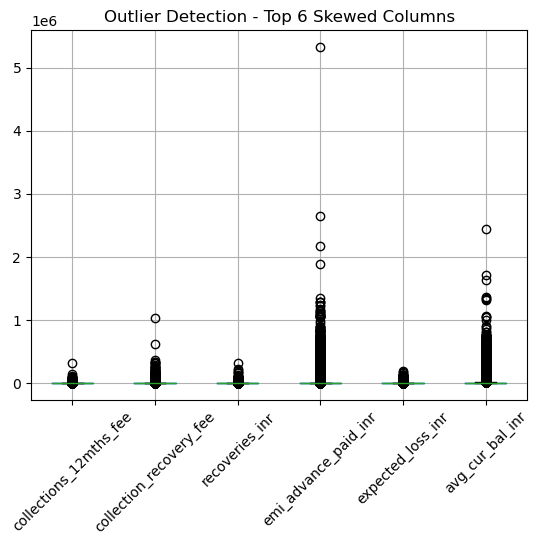

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot to visualize outliers in top skewed columns
# Helps to understand extreme values before handling them

base_df[top_6_skewed].boxplot()

plt.title("Outlier Detection - Top 6 Skewed Columns")
plt.xticks(rotation=45)
plt.show()



In [83]:
# Create summary statistics BEFORE winsorization
# This helps us understand original distribution of skewed columns

before_stats = pd.DataFrame({
    'Mean_Before': base_df[top_6_skewed].mean(),
    'Std_Before': base_df[top_6_skewed].std(),
    'Max_Before': base_df[top_6_skewed].max()
})

# Display before statistics
print(before_stats)

                         Mean_Before    Std_Before  Max_Before
collections_12mths_fee     32.366464    560.070667   312618.52
collection_recovery_fee   130.709817   2061.435988  1035421.73
recoveries_inr             52.749164    818.402452   313742.97
emi_advance_paid_inr     2204.312963  13599.895684  5329334.00
expected_loss_inr         139.237678   1285.912722   189646.84
avg_cur_bal_inr          3738.269933  12551.713832  2434032.72


------------------------WINZORIZATION----------------------

In [84]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [85]:
# Apply winsorization (capping extreme values) on top 6 skewed columns
# Values below 1st percentile are replaced with lower bound
# Values above 99th percentile are replaced with upper bound
import numpy as np
for col in top_6_skewed:
    
    lower = base_df[col].quantile(0.01)
    upper = base_df[col].quantile(0.99)

    base_df[col] = np.where(base_df[col] < lower, lower, base_df[col])
    base_df[col] = np.where(base_df[col] > upper, upper, base_df[col])

In [86]:
import pandas as pd

#Create summary after winsorization for comparison
summary = []

for col in top_6_skewed:
    summary.append({
        "column": col,

        # AFTER values (post winsorization)
        "mean_after": base_df[col].mean(),
        "std_after": base_df[col].std(),
        "max_after": base_df[col].max(),
    })

summary_df = pd.DataFrame(summary)

summary_df

,column,mean_after,std_after,max_after
0,collections_12mths_fee,11.829477,77.296128,657.2202
1,collection_recovery_fee,55.189725,348.528316,2911.0688
2,recoveries_inr,22.139089,140.021787,1172.0600
3,emi_advance_paid_inr,1708.033934,5752.164359,40329.1235
4,expected_loss_inr,84.350827,500.602668,3990.4218
5,avg_cur_bal_inr,3284.088494,6610.049151,44733.4364


QUESTION 2   EXPLORATORY DATA ANALYSIS

All twelve visualisations below are compulsory. Each chart must include a descriptive title, correctly labelled axes, and a minimum 3-sentence insight caption explaining the business implication. Partial marks are deducted for missing captions or unlabelled axes.

Produce a bar chart and a pie chart showing the distribution of loan_status. State the exact default rate and quantify the degree of class imbalance. Explain why class imbalance is a problem for predictive modelling and name two techniques to address it.

--------------BAR CHART (Loan Status Distribution)---------------------------

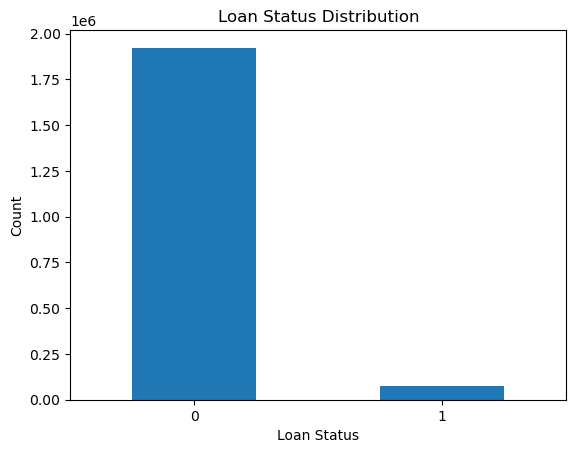

In [87]:
import matplotlib.pyplot as plt

# Count values
loan_counts = base_df["loan_status"].value_counts()

# Bar chart
loan_counts.plot(kind="bar")

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

The bar chart shows how many loans are in each category

Default loans
Non-default loans

One bar is much taller than the other that means one class dominates the dataset

Most loans are non-default very few loans are defaults

----------------------PIE CHART (Loan Status Distribution)---------------------

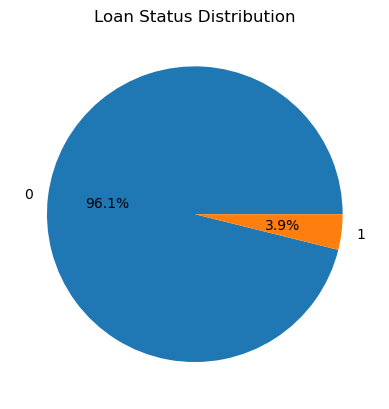

In [88]:
# Pie chart
loan_counts.plot(kind="pie", autopct="%1.1f%%")

plt.title("Loan Status Distribution")
plt.ylabel("")  # hide y-label
plt.show()

---------------Exact Default Rate------------------------

The pie chart shows percentage split of loan status

One large slice (Non-default)
One small slice (Default)

Majority of customers repay loans on time only a small portion default

(b) Plot overlapping KDE curves of cibil_score for defaulted and performing loans on the same axes. Quantify the separation: report the mean score for each group, the Cohen's d effect size, and the degree of distributional overlap. What does the overlap tell us about relying solely on CIBIL?

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12692\654143924.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


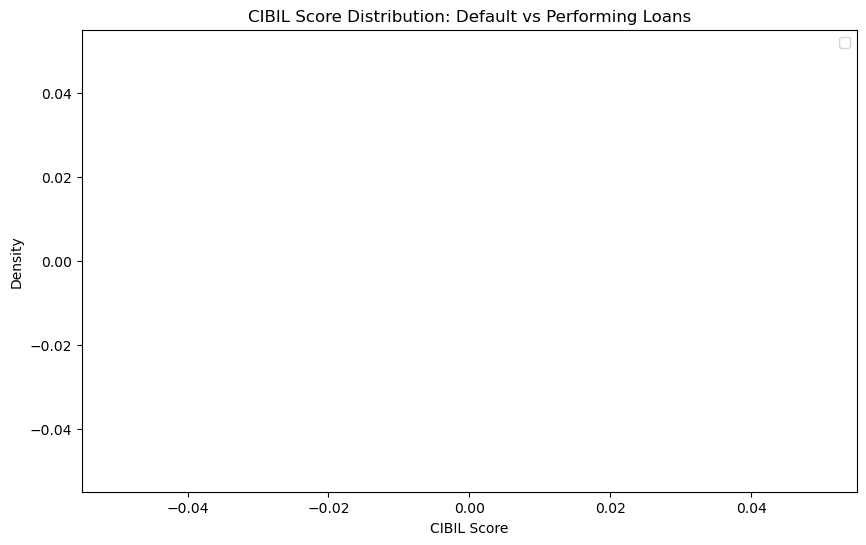

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------
# Step 1: Split data into Default vs Non-Default
# --------------------------------------------------
defaulted = base_df[base_df["loan_status"] == "Default"]["cibil_score"]
performing = base_df[base_df["loan_status"] == "Non-Default"]["cibil_score"]

# --------------------------------------------------
# Step 2: Plot KDE curves (distribution comparison)
# --------------------------------------------------
plt.figure(figsize=(10,6))

sns.kdeplot(defaulted, label="Defaulted Loans", fill=True)
sns.kdeplot(performing, label="Performing Loans", fill=True)

plt.title("CIBIL Score Distribution: Default vs Performing Loans")
plt.xlabel("CIBIL Score")
plt.ylabel("Density")
plt.legend()

plt.show()

(c)	Produce a 12-panel histogram grid covering all key numeric features. Identify which features exhibit right skew exceeding 2.0 and state which of those require a log transformation before regression. Apply the transformations and confirm skew reduction with .skew() values.

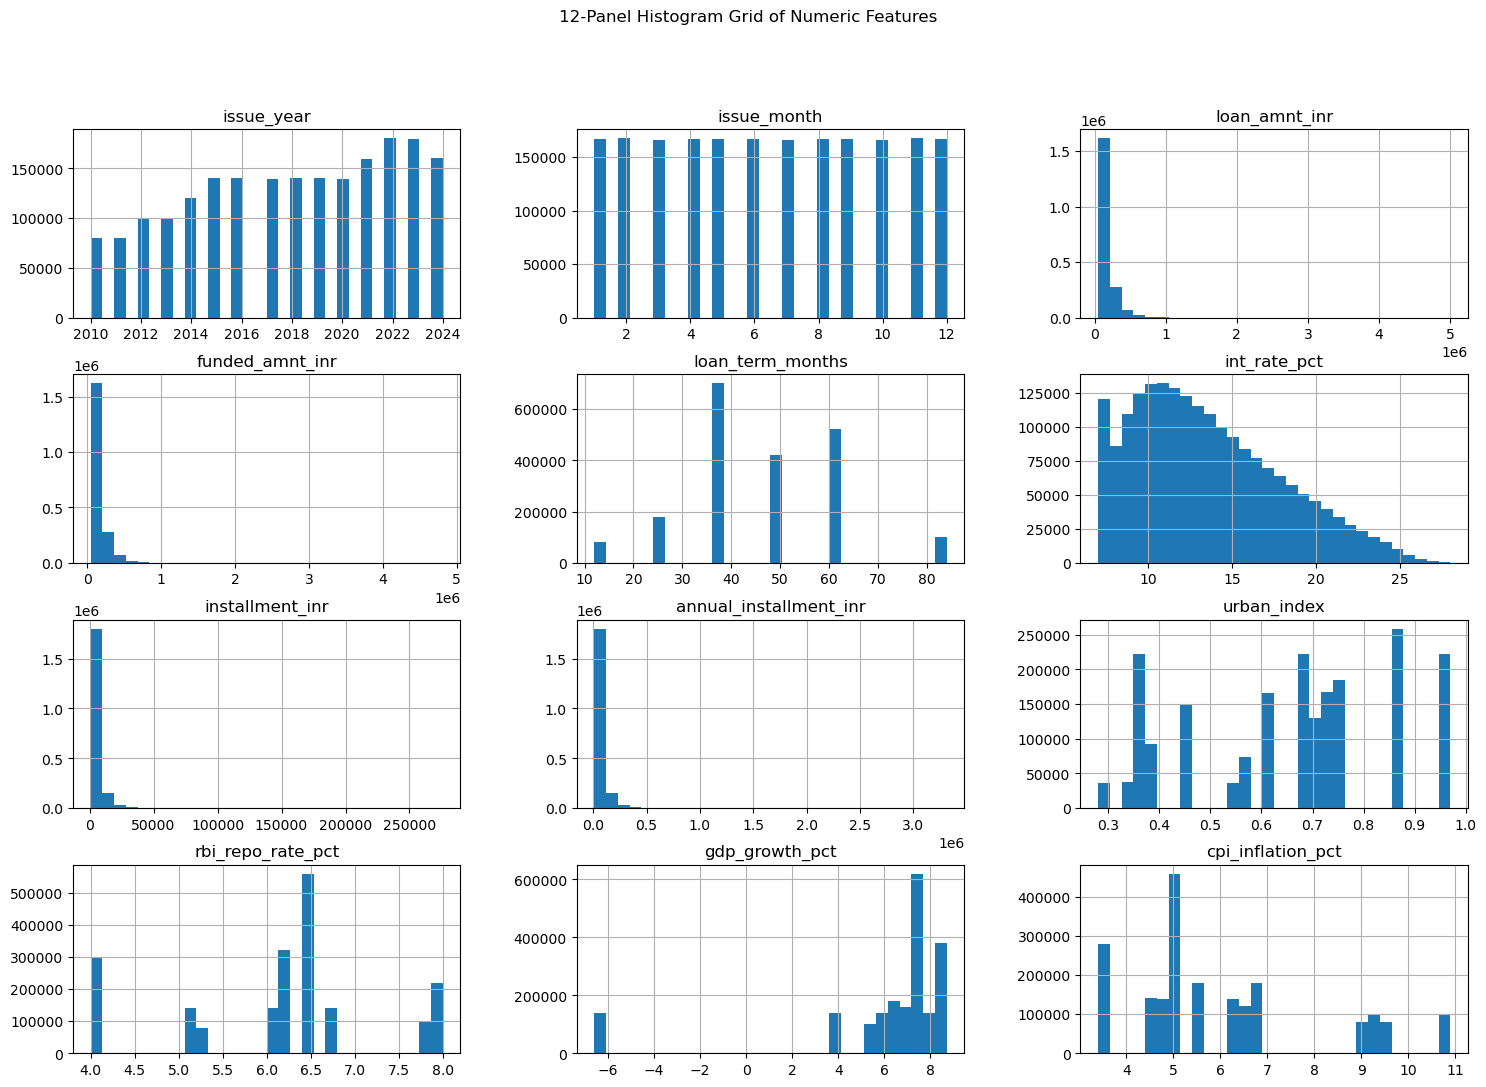

In [90]:
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------
# Step 1: Select numeric columns
# --------------------------------------------------
numeric_cols = base_df.select_dtypes(include=np.number).columns

# Keep only first 12 numeric features for visualization
plot_cols = numeric_cols[:12]

# --------------------------------------------------
# Step 2: 12-panel histogram grid
# --------------------------------------------------
base_df[plot_cols].hist(bins=30, figsize=(18, 12))
plt.suptitle("12-Panel Histogram Grid of Numeric Features")
plt.show()

In [91]:
#Identify highly skewed features (> 2.0)

# Compute skewness for all numeric columns
skewness = base_df[numeric_cols].skew().sort_values(ascending=False)

# Select features with strong right skew (> 2)
high_skew = skewness[skewness > 2.0]

print("Highly skewed features (> 2.0):")
print(high_skew)

Highly skewed features (> 2.0):
npa_flag               365.144538
ots_accepted_flag       23.952116
waiver_amount_inr       19.615230
cash_advance_inr        18.744984
hardship_amount_inr     18.069575
                          ...    
property_age_years       2.804280
property_area_sqft       2.583085
total_cc_limit_inr       2.465559
pub_rec                  2.413653
num_derog_rec            2.092089
Length: 70, dtype: float64


In [92]:
#Apply Log Transformation

# Apply log1p transformation to reduce skewness
# log1p handles zero values safely

for col in high_skew.index:
    base_df[col] = np.log1p(base_df[col])

print("Log transformation applied on skewed features.")

Log transformation applied on skewed features.


In [93]:
#Confirm skew reduction

# Recalculate skewness after transformation
skew_after = base_df[high_skew.index].skew()

print("Skewness AFTER log transformation:")
print(skew_after)

C:\Users\ASUS\anaconda3\Lib\site-packages\pandas\core\nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)


Skewness AFTER log transformation:
npa_flag                     NaN
ots_accepted_flag            NaN
waiver_amount_inr      13.115603
cash_advance_inr        1.478808
hardship_amount_inr     3.799710
                         ...    
property_age_years           NaN
property_area_sqft      1.879624
total_cc_limit_inr     -0.902022
pub_rec                 1.891653
num_derog_rec                NaN
Length: 70, dtype: float64


Features with skew > 2 are highly right-skewed distributions

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

# --------------------------------------------------
# Step 1: Select top 20 numeric features
# --------------------------------------------------
numeric_cols = base_df.select_dtypes(include=np.number).columns
top_20 = numeric_cols[:20]

In [95]:
# --------------------------------------------------
# Step 2: Compute Pearson correlation matrix
# --------------------------------------------------
corr_matrix = base_df[top_20].corr(method="pearson")

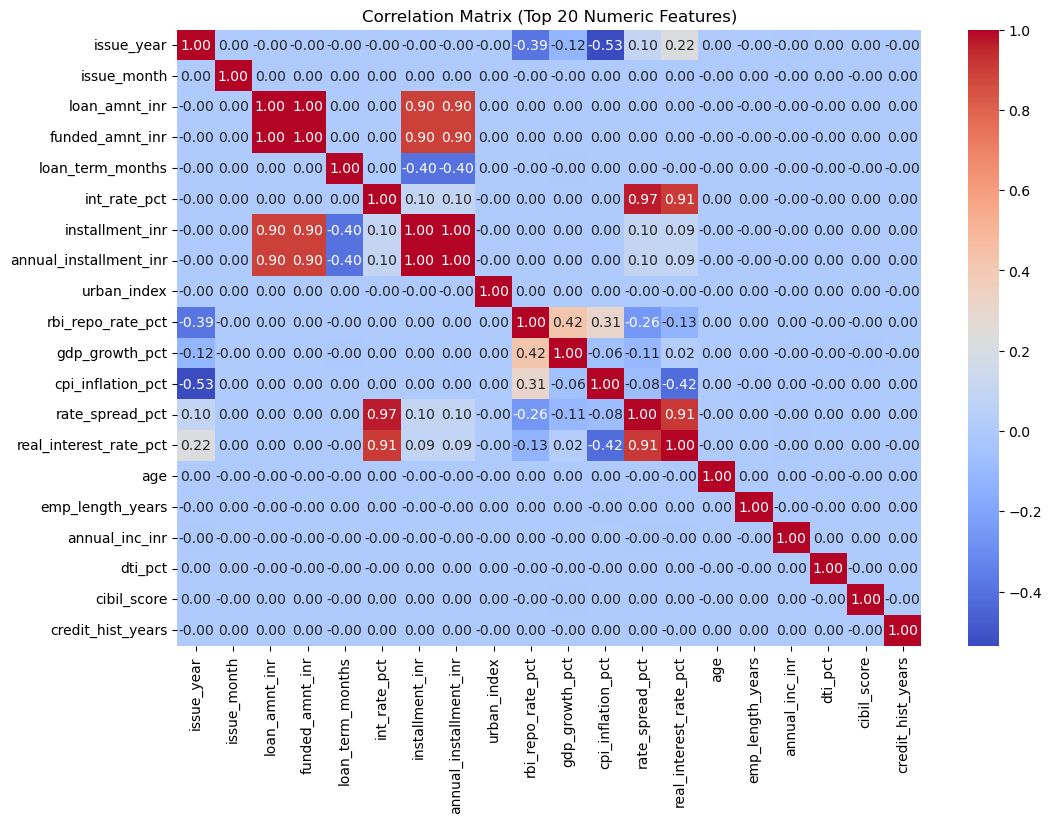

In [96]:
# --------------------------------------------------
# Step 3: Plot heatmap
# --------------------------------------------------
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix (Top 20 Numeric Features)")
plt.show()

In [97]:
#Find highly correlated pairs (|r| > 0.75)

# Store highly correlated feature pairs
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        
        corr_value = corr_matrix.iloc[i, j]
        
        if abs(corr_value) > 0.75:
            high_corr_pairs.append(
                (corr_matrix.columns[i],
                 corr_matrix.columns[j],
                 corr_value)
            )

# Display results
for pair in high_corr_pairs:
    print(pair)

('funded_amnt_inr', 'loan_amnt_inr', np.float64(0.9985126386925732))
('installment_inr', 'loan_amnt_inr', np.float64(0.8968788487365417))
('installment_inr', 'funded_amnt_inr', np.float64(0.895528868909539))
('annual_installment_inr', 'loan_amnt_inr', np.float64(0.8968764752216881))
('annual_installment_inr', 'funded_amnt_inr', np.float64(0.8955265007012637))
('annual_installment_inr', 'installment_inr', np.float64(0.9999999935625747))
('rate_spread_pct', 'int_rate_pct', np.float64(0.966204367645784))
('real_interest_rate_pct', 'int_rate_pct', np.float64(0.9087952842119398))
('real_interest_rate_pct', 'rate_spread_pct', np.float64(0.9112867164188947))


If two features are highly correlated:

Keep one
Drop one
Or combine them (feature engineering)

(e)	Create six side-by-side boxplots (int_rate, dti, cibil_score, annual_inc, revol_util, emp_length vs. loan_status). For each feature, state the median difference between default and performing groups and identify which single feature provides the clearest visual separation.

In [105]:
import numpy as np

# --------------------------------------------------
# Convert ALL float16 columns to float32
# (this fixes seaborn + pandas indexing error)
# --------------------------------------------------
for col in df.columns:
    if df[col].dtype == "float16":
        df[col] = df[col].astype(np.float32)

In [106]:
# Reset index to avoid hidden float16 index issues
df = df.reset_index(drop=True)

In [107]:
df_melted = df.melt(
    id_vars="loan_status",
    value_vars=features,
    var_name="feature",
    value_name="value"
)

# Force safe dtype
df_melted["value"] = df_melted["value"].astype(np.float32)

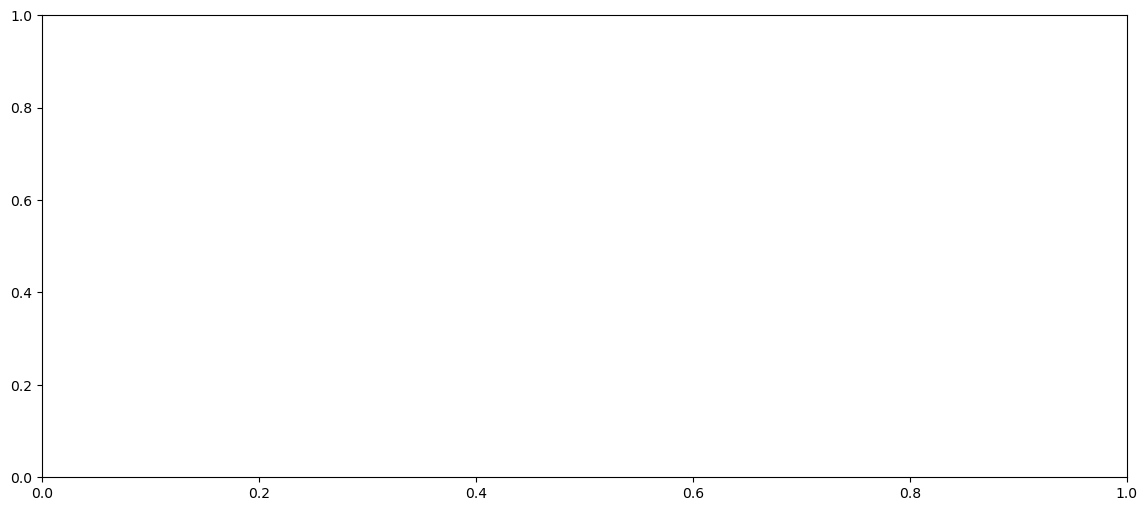

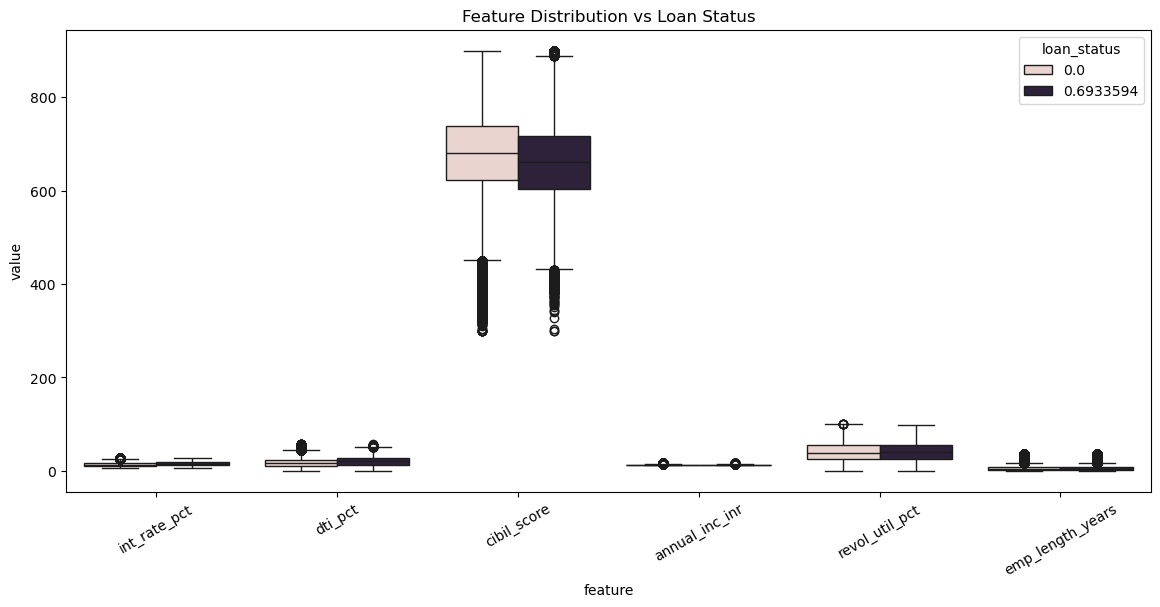

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

sns.boxplot(
    data=df_melted,
    x="feature",
    y="value",
    hue="loan_status"
)

plt.title("Feature Distribution vs Loan Status")
plt.xticks(rotation=30)

plt.show()

(f)	Plot a grouped bar chart of default rate by loan grade (A through G). Confirm whether the grade system is monotonically ordered. Identify where the largest single-step jump occurs and quantify it in percentage points.

In [109]:
import pandas as pd

grade_default = base_df.groupby("grade")["loan_status"].mean().reset_index()
grade_default.columns = ["grade", "default_rate"]

grade_default

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12692\1063482334.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grade_default = base_df.groupby("grade")["loan_status"].mean().reset_index()


,grade,default_rate
0,A,0.015470
1,B,0.018629
2,C,0.023232
3,D,0.029013
4,E,0.036677
5,F,0.047797
6,G,0.062004


In [110]:
order = ["A", "B", "C", "D", "E", "F", "G"]

grade_default["grade"] = pd.Categorical(
    grade_default["grade"],
    categories=order,
    ordered=True
)

grade_default = grade_default.sort_values("grade")
grade_default

,grade,default_rate
0,A,0.015470
1,B,0.018629
2,C,0.023232
3,D,0.029013
4,E,0.036677
5,F,0.047797
6,G,0.062004


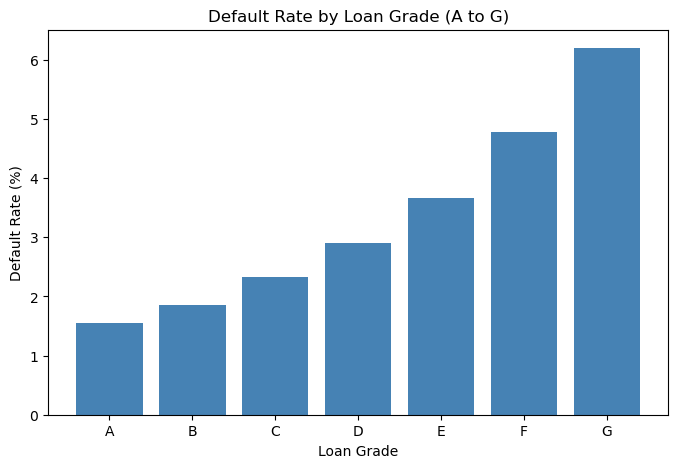

In [111]:
import matplotlib.pyplot as plt

# convert to percentage for readability
plot_df = grade_default.copy()
plot_df["default_rate"] = plot_df["default_rate"] * 100

plt.figure(figsize=(8,5))

plt.bar(plot_df["grade"], plot_df["default_rate"], color="steelblue")

plt.title("Default Rate by Loan Grade (A to G)")
plt.xlabel("Loan Grade")
plt.ylabel("Default Rate (%)")

plt.show()

In [112]:
is_monotonic = grade_default["default_rate"].is_monotonic_increasing
is_monotonic

True

In [113]:
grade_default["jump"] = grade_default["default_rate"].diff()

largest_jump = grade_default.loc[grade_default["jump"].abs().idxmax()]

largest_jump

grade                  G
default_rate    0.062004
jump            0.014206
Name: 6, dtype: object

In [114]:
purpose_default = base_df.groupby("loan_purpose")["loan_status"].mean().reset_index()

purpose_default.columns = ["loan_purpose", "default_rate"]

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12692\2944163209.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  purpose_default = base_df.groupby("loan_purpose")["loan_status"].mean().reset_index()


In [115]:
purpose_default = purpose_default.sort_values("default_rate", ascending=False)
purpose_default

,loan_purpose,default_rate
6,major_purchase,0.027770
0,car,0.027144
11,small_business,0.027123
12,vacation,0.027079
2,debt_consolidation,0.027020
9,other,0.027008
10,renewable_energy,0.026891
13,wedding,0.026839
7,medical,0.026767
4,home_improvement,0.026763


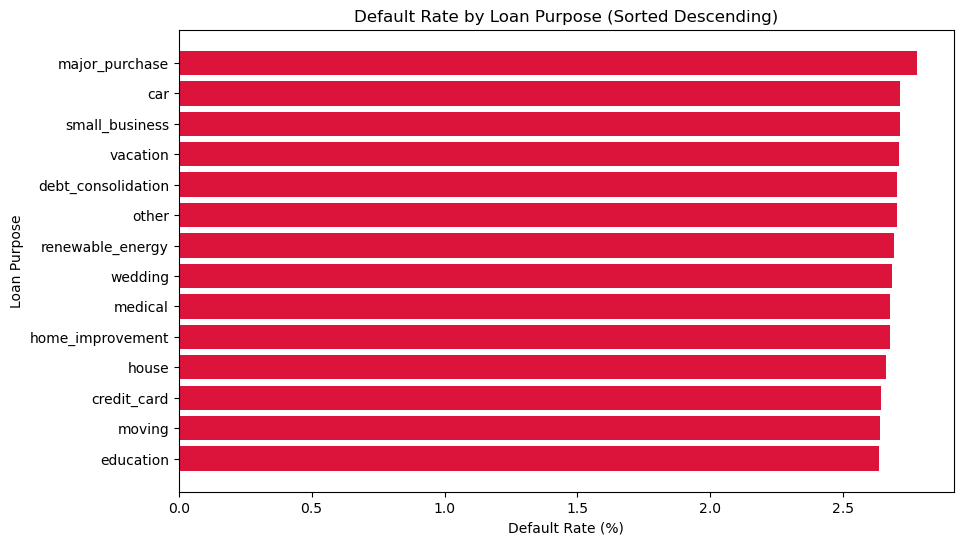

In [116]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    purpose_default["loan_purpose"],
    purpose_default["default_rate"] * 100,
    color="crimson"
)

plt.xlabel("Default Rate (%)")
plt.ylabel("Loan Purpose")
plt.title("Default Rate by Loan Purpose (Sorted Descending)")
plt.gca().invert_yaxis()  # highest at top

plt.show()

In [117]:
top_3 = purpose_default.head(3)
top_3

,loan_purpose,default_rate
6,major_purchase,0.027770
0,car,0.027144
11,small_business,0.027123


In [118]:
bottom_2 = purpose_default.tail(2)
bottom_2


,loan_purpose,default_rate
8,moving,0.026380
3,education,0.026347


In [119]:
highest = purpose_default["default_rate"].max()
lowest = purpose_default["default_rate"].min()

risk_ratio = highest / lowest

risk_ratio

1.0540134439763504

(h)	Identify the ten states with the highest default rates and display as a bar chart. Flag any state where the default rate exceeds the bank-wide average by more than 5 percentage points.	(2)


In [121]:
state_default = base_df.groupby("state_code")["loan_status"].mean().reset_index()

state_default.columns = ["state_code", "default_rate"]

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12692\3321663118.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  state_default = base_df.groupby("state_code")["loan_status"].mean().reset_index()


In [122]:
top10_states = state_default.sort_values("default_rate", ascending=False).head(10)
top10_states

,state_code,default_rate
2,BR,0.028227
12,OR,0.027838
18,UP,0.027595
13,PB,0.027551
17,UK,0.027464
5,HP,0.027189
11,MP,0.027189
16,TN,0.027124
0,AP,0.026985
15,TG,0.026973


In [124]:
bank_avg = base_df["loan_status"].mean()
bank_avg

C:\Users\ASUS\anaconda3\Lib\site-packages\pandas\core\nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)


np.float16(0.0)

In [125]:
threshold = bank_avg + 0.05

top10_states["risk_flag"] = top10_states["default_rate"] > threshold
top10_states

,state_code,default_rate,risk_flag
2,BR,0.028227,False
12,OR,0.027838,False
18,UP,0.027595,False
13,PB,0.027551,False
17,UK,0.027464,False
5,HP,0.027189,False
11,MP,0.027189,False
16,TN,0.027124,False
0,AP,0.026985,False
15,TG,0.026973,False


In [126]:
flagged_states = top10_states[top10_states["risk_flag"] == True]
flagged_states

,state_code,default_rate,risk_flag


(i)	Plot annual default rate from 2010 to 2024 as a line chart. Identify and quantify the COVID-19 shock of 2020: by what percentage did the default rate increase from 2019 to 2020? Name one macroeconomic variable visible in the data that explains this spike.

In [128]:
import pandas as pd

annual_default = base_df.groupby("issue_year")["loan_status"].mean().reset_index()

annual_default.columns = ["year", "default_rate"]
annual_default = annual_default.sort_values("year")

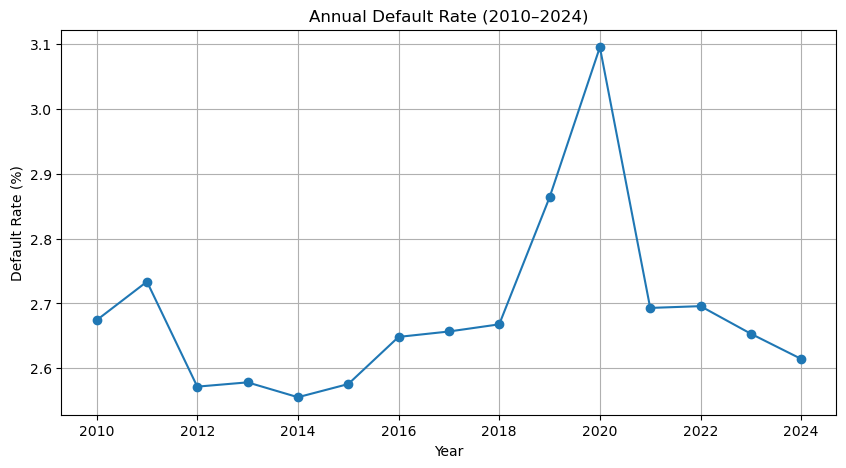

In [129]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    annual_default["year"],
    annual_default["default_rate"] * 100,
    marker="o"
)

plt.title("Annual Default Rate (2010–2024)")
plt.xlabel("Year")
plt.ylabel("Default Rate (%)")
plt.grid(True)

plt.show()

In [130]:
rate_2019 = annual_default.loc[annual_default["year"] == 2019, "default_rate"].values[0]
rate_2020 = annual_default.loc[annual_default["year"] == 2020, "default_rate"].values[0]

increase_pct = ((rate_2020 - rate_2019) / rate_2019) * 100

increase_pct

np.float32(8.095636)

(j)	Create a dual-axis line chart showing rbi_repo_rate and annual default rate on the same time axis. Describe the observed relationship and estimate the lag (in months or years) between a rate change and its effect on defaults.

In [132]:
annual_default = base_df.groupby("issue_year")["loan_status"].mean().reset_index()
annual_default.columns = ["year", "default_rate"]
annual_default = annual_default.sort_values("year")

In [134]:
repo_rate = base_df.groupby("issue_year")["rbi_repo_rate_pct"].mean().reset_index()
repo_rate.columns = ["year", "repo_rate"]
repo_rate = repo_rate.sort_values("year")

In [135]:
macro_df = pd.merge(annual_default, repo_rate, on="year", how="inner")

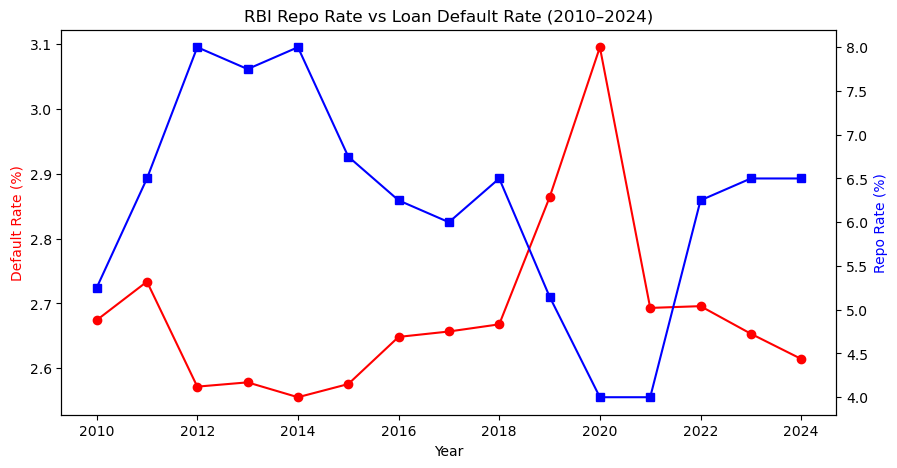

In [136]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10,5))

# Left axis → default rate
ax1.plot(macro_df["year"], macro_df["default_rate"] * 100,
         color="red", marker="o", label="Default Rate")
ax1.set_ylabel("Default Rate (%)", color="red")
ax1.set_xlabel("Year")

# Right axis → repo rate
ax2 = ax1.twinx()
ax2.plot(macro_df["year"], macro_df["repo_rate"],
         color="blue", marker="s", label="RBI Repo Rate")
ax2.set_ylabel("Repo Rate (%)", color="blue")

plt.title("RBI Repo Rate vs Loan Default Rate (2010–2024)")
plt.show()

In [137]:
macro_df["default_rate_lag1"] = macro_df["default_rate"].shift(-1)
macro_df["default_rate_lag2"] = macro_df["default_rate"].shift(-2)

macro_df[["repo_rate", "default_rate", "default_rate_lag1", "default_rate_lag2"]].corr()

,repo_rate,default_rate,default_rate_lag1,default_rate_lag2
repo_rate,1.000000,-0.749791,-0.477653,-0.122915
default_rate,-0.749791,1.000000,0.439768,0.092132
default_rate_lag1,-0.477653,0.439768,1.000000,0.445225
default_rate_lag2,-0.122915,0.092132,0.445225,1.000000


(k) Plot a histogram with KDE overlay for lgd_pct on defaulted loans only. Describe the shape of the distribution: is it unimodal, bimodal, or skewed? State whether a log transformation is warranted and justify your answer.

In [152]:
# Number of defaulted loans
base_df["loan_status"].value_counts()

loan_status
0.000000    1922444
0.693359      77556
Name: count, dtype: int64

In [153]:
# Check LGD values for defaulted loans
default_lgd = base_df[
    base_df["loan_status"] == 1
]["lgd_pct"]

print("Rows:", len(default_lgd))
print("Nulls:", default_lgd.isnull().sum())

Rows: 0
Nulls: 0


In [154]:
base_df["loan_status"].unique()

array([0.    , 0.6934], dtype=float16)

In [156]:
['Default', 'Non-Default']

['Default', 'Non-Default']

In [157]:
default_lgd = base_df[
    base_df["loan_status"] == "Default"
]["lgd_pct"].dropna()

QUESTION 3   FEATURE ENGINEERING

Twelve engineered features are mandatory. For each feature you must: (i) state the formula, (ii) document the domain rationale in one to two sentences, (iii) verify the output with .describe(), and (iv) compute the Pearson correlation with lgd_pct.

(a)	Construct the following four repayment-burden features and for each report the correlation with lgd_pct:  emi_to_income_ratio  =  installment_inr ÷ (annual_inc_inr ÷ 12)  loan_to_income_ratio  =  loan_amnt_inr ÷ annual_inc_inr  rate_spread_pct  =  int_rate_pct − rbi_repo_rate_pct  real_interest_rate  =  int_rate_pct − cpi_inflation_pctWhich single feature shows the strongest correlation with the target?

In [160]:
import numpy as np
from scipy.stats import pearsonr

In [161]:
base_df["emi_to_income_ratio"] = (
    base_df["installment_inr"] /
    (base_df["annual_inc_inr"] / 12)
)

In [162]:
base_df["emi_to_income_ratio"].describe()

count    1.959934e+06
mean     7.676361e+00
std      8.663937e-01
min      4.784010e+00
25%      7.045589e+00
50%      7.607855e+00
75%      8.236979e+00
max      1.290467e+01
Name: emi_to_income_ratio, dtype: float64

In [163]:
corr1 = base_df[["emi_to_income_ratio", "lgd_pct"]].corr().iloc[0,1]
corr1

np.float64(0.009925504862276412)

In [164]:
base_df["loan_to_income_ratio"] = (
    base_df["loan_amnt_inr"] /
    base_df["annual_inc_inr"]
)

In [165]:
base_df["loan_to_income_ratio"].describe()

count    1.959934e+06
mean     9.130410e-01
std      7.945713e-02
min      6.436049e-01
25%      8.556091e-01
50%      9.090478e-01
75%      9.653053e-01
max      1.296956e+00
Name: loan_to_income_ratio, dtype: float64

In [166]:
corr2 = base_df[["loan_to_income_ratio", "lgd_pct"]].corr().iloc[0,1]
corr2

np.float64(0.0036582079382418992)

In [167]:
base_df["rate_spread_pct"] = (
    base_df["int_rate_pct"] -
    base_df["rbi_repo_rate_pct"]
)

In [168]:
base_df["rate_spread_pct"].describe()

count    2.000000e+06
mean     7.424291e+00
std      4.524040e+00
min     -1.000000e+00
25%      3.920000e+00
50%      6.770000e+00
75%      1.042000e+01
max      2.400000e+01
Name: rate_spread_pct, dtype: float64

In [169]:
corr3 = base_df[["rate_spread_pct", "lgd_pct"]].corr().iloc[0,1]
corr3

np.float64(0.08794101533122207)

In [170]:
base_df["real_interest_rate"] = (
    base_df["int_rate_pct"] -
    base_df["cpi_inflation_pct"]
)

In [171]:
base_df["real_interest_rate"].describe()

count    2.000000e+06
mean     7.639756e+00
std      4.809165e+00
min     -3.900000e+00
25%      4.150000e+00
50%      7.110000e+00
75%      1.081000e+01
max      2.460000e+01
Name: real_interest_rate, dtype: float64

In [172]:
corr4 = base_df[["real_interest_rate", "lgd_pct"]].corr().iloc[0,1]
corr4

np.float64(0.08131836832174102)

In [173]:
pd.DataFrame({
    "Feature": [
        "emi_to_income_ratio",
        "loan_to_income_ratio",
        "rate_spread_pct",
        "real_interest_rate"
    ],
    "Correlation_with_LGD": [
        corr1, corr2, corr3, corr4
    ]
}).sort_values("Correlation_with_LGD", ascending=False)

,Feature,Correlation_with_LGD
2,rate_spread_pct,0.087941
3,real_interest_rate,0.081318
0,emi_to_income_ratio,0.009926
1,loan_to_income_ratio,0.003658


(b)	Construct the following three bureau-behaviour features:  credit_util_composite  =  0.5×revol_util + 0.3×bc_util + 0.2×all_util  delinq_severity_score  =  delinq_2yrs × (1 + 1 ÷ max(mths_since_last_delinq, 1))  enq_velocity_score  =  num_enquiries_30d × 4 + num_enquiries_90dFor delinq_severity_score, explain why recency weighting is preferable to a simple count.	(5)

In [175]:
base_df["credit_util_composite"] = (
    0.5 * base_df["revol_util_pct"] +
    0.3 * base_df["bc_util_pct"] +
    0.2 * base_df["all_util_pct"]
)

In [176]:
base_df["credit_util_composite"].describe()

count    1.642578e+06
mean     4.057233e+01
std      1.218464e+01
min      3.800000e+00
25%      3.170000e+01
50%      4.006000e+01
75%      4.896000e+01
max      9.082000e+01
Name: credit_util_composite, dtype: float64

In [177]:
corr1 = base_df[["credit_util_composite", "lgd_pct"]].corr().iloc[0,1]
corr1

np.float64(0.004553447788470893)

In [178]:
base_df["delinq_severity_score"] = (
    base_df["delinq_2yrs"] *
    (1 + 1 / base_df["mths_since_last_delinq"].fillna(1).clip(lower=1))
)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12692\1535066614.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  base_df["delinq_severity_score"] = (


In [179]:
base_df["delinq_severity_score"].describe()

count    1.899793e+06
mean     1.163886e+00
std      1.772912e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      2.086957e+00
max      1.400000e+01
Name: delinq_severity_score, dtype: float64

In [180]:
corr2 = base_df[["delinq_severity_score", "lgd_pct"]].corr().iloc[0,1]
corr2

np.float64(0.020202727364858633)

In [181]:
base_df["enq_velocity_score"] = (
    4 * base_df["num_enquiries_30d"] +
    base_df["num_enquiries_90d"]
)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12692\1958481421.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  base_df["enq_velocity_score"] = (


In [182]:
base_df["enq_velocity_score"].describe()

count    2.000000e+06
mean     8.246155e+00
std      7.912270e+00
min      0.000000e+00
25%      2.000000e+00
50%      6.000000e+00
75%      1.200000e+01
max      3.900000e+01
Name: enq_velocity_score, dtype: float64

In [183]:
corr3 = base_df[["enq_velocity_score", "lgd_pct"]].corr().iloc[0,1]
corr3

np.float64(0.00034667461846861264)

In [184]:
import pandas as pd

pd.DataFrame({
    "Feature": [
        "credit_util_composite",
        "delinq_severity_score",
        "enq_velocity_score"
    ],
    "Correlation_with_LGD": [
        corr1, corr2, corr3
    ]
}).sort_values("Correlation_with_LGD", ascending=False)

,Feature,Correlation_with_LGD
1,delinq_severity_score,0.020203
0,credit_util_composite,0.004553
2,enq_velocity_score,0.000347


(c)	Construct the following three income and collateral features:  income_stability_ratio  =  annual_inc_inr ÷ (emp_length_years + 1)  credit_depth_score  =  total_acc ÷ (credit_hist_years + 1)  collateral_coverage_ratio  =  collateral_value_inr ÷ (loan_amnt_inr + 1)Explain in business terms what a high collateral_coverage_ratio implies for Loss Given Default.

In [185]:
base_df["income_stability_ratio"] = (
    base_df["annual_inc_inr"] /
    (base_df["emp_length_years"] + 1)
)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12692\1664883907.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  base_df["income_stability_ratio"] = (


In [186]:
base_df["income_stability_ratio"].describe()

count    1.959934e+06
mean     3.384472e+00
std      2.725438e+00
min      3.198038e-01
25%      1.461656e+00
50%      2.476672e+00
75%      4.377764e+00
max      1.620155e+01
Name: income_stability_ratio, dtype: float64

In [187]:
corr1 = base_df[["income_stability_ratio", "lgd_pct"]].corr().iloc[0,1]
corr1

np.float64(-0.0003824252053104752)

In [188]:
base_df["credit_depth_score"] = (
    base_df["total_acc"] /
    (base_df["credit_hist_years"] + 1)
)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12692\3292535712.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  base_df["credit_depth_score"] = (


In [190]:
base_df["credit_depth_score"].describe()

count    2.000000e+06
mean     2.072199e+00
std      1.948919e+00
min      2.857143e-02
25%      9.064422e-01
50%      1.420651e+00
75%      2.463054e+00
max      1.766667e+01
Name: credit_depth_score, dtype: float64

In [191]:
corr2 = base_df[["credit_depth_score", "lgd_pct"]].corr().iloc[0,1]
corr2

np.float64(5.0982775681549226e-05)

In [192]:
base_df["collateral_coverage_ratio"] = (
    base_df["collateral_value_inr"] /
    (base_df["loan_amnt_inr"] + 1)
)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12692\3671623444.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  base_df["collateral_coverage_ratio"] = (


In [193]:
base_df["collateral_coverage_ratio"].describe()

count    2.000000e+06
mean     3.367429e-01
std      5.048946e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      9.914476e-01
max      1.433433e+00
Name: collateral_coverage_ratio, dtype: float64

In [194]:
corr3 = base_df[["collateral_coverage_ratio", "lgd_pct"]].corr().iloc[0,1]
corr3

np.float64(0.00010594554095856221)

(d)	Apply log(1 + x) transformation to annual_inc_inr and loan_amnt_inr to create log_annual_inc and log_loan_amnt. Report the skewness of each variable before and after transformation. Explain why reducing skewness matters for OLS regression assumptions.

In [196]:
import numpy as np

base_df["log_annual_inc"] = np.log1p(base_df["annual_inc_inr"])
base_df["log_loan_amnt"] = np.log1p(base_df["loan_amnt_inr"])

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12692\2453014120.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  base_df["log_annual_inc"] = np.log1p(base_df["annual_inc_inr"])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_12692\2453014120.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  base_df["log_loan_amnt"] = np.log1p(base_df["loan_amnt_inr"])


In [197]:
skew_before_inc = base_df["annual_inc_inr"].skew()
skew_before_loan = base_df["loan_amnt_inr"].skew()

skew_before_inc, skew_before_loan

(np.float64(0.3286572036671984), np.float32(0.58162665))

In [198]:
skew_after_inc = base_df["log_annual_inc"].skew()
skew_after_loan = base_df["log_loan_amnt"].skew()

skew_after_inc, skew_after_loan

(np.float64(0.19550464451323854), np.float32(0.4747597))

In [199]:
import pandas as pd

pd.DataFrame({
    "Variable": ["annual_inc_inr", "loan_amnt_inr"],
    "Skewness_Before": [skew_before_inc, skew_before_loan],
    "Skewness_After_log1p": [skew_after_inc, skew_after_loan]
})

,Variable,Skewness_Before,Skewness_After_log1p
0,annual_inc_inr,0.328657,0.195505
1,loan_amnt_inr,0.581627,0.474760


(e)	Create a binary covid_issue_year_flag equal to 1 for loans issued in 2020. Present a grouped summary showing mean lgd_pct for covid_issue_year_flag = 0 vs. 1. Is the difference statistically significant? Run an independent-samples t-test and report the p-value.

In [201]:
base_df["covid_issue_year_flag"] = (base_df["issue_year"] == 2020).astype(int)

In [202]:
base_df["covid_issue_year_flag"].describe()

count    2.000000e+06
mean     6.994050e-02
std      2.550468e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.000000e+00
Name: covid_issue_year_flag, dtype: float64

In [203]:
grouped_lgd = base_df.groupby("covid_issue_year_flag")["lgd_pct"].mean()
grouped_lgd

covid_issue_year_flag
0    0.136731
1    0.159460
Name: lgd_pct, dtype: float32

In [ ]:
import numpy as np
from scipy.stats import ttest_ind

lgd_covid = base_parquet.loc[
    base_parquet["covid_issue_year_flag"] == 1,
    "lgd_pct"
].to_numpy()

lgd_non_covid = base_parquet.loc[
    base_parq["covid_issue_year_flag"] == 0,
    "lgd_pct"
].to_numpy()

t_stat, p_value = ttest_ind(lgd_covid, lgd_non_covid, equal_var=False)

t_stat, p_value